In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from math import e
from scipy.optimize import minimize
from IPython.display import clear_output
from scipy import optimize
from scipy.stats import norm
import pickle
from scipy import integrate
from scipy import stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

In [2]:
pd.options.display.max_seq_items = 2000

In [3]:
data = pd.read_excel('data.ods')

In [4]:
data['T (ºC)'] = data['T_R_K'] - 273

In [5]:
data = data.loc[(data['CINÉTICA'] == 1) | (data['DESATIVAÇÃO'] == 1)]
# data = data.loc[((data['F_C2H6_s_mol_s'] != 0) & (data['F_C3H8_s_mol_s'] != 0))]

In [6]:
data = data.copy()

In [7]:
data[['F_Olef_C2_e', 'F_Olef_C3_e', 
    'F_Olef_C9_e', 'F_Olef_C10_e', 'F_Olef_C11_e', 
   'F_Olef_C12_e', 'F_Olef_C13_e', 'F_Olef_C14_e', 'F_Olef_C15_e', 
     'F_Olef_C16_e', 'F_Olef_C17_e', 'F_Olef_C18_e',

    
    'F_C1_e', 'F_C2_e', 'F_C3_e', 'F_C9_e', 'F_C10_e', 'F_C11_e', 
      'F_C12_e', 'F_C13_e', 'F_C14_e', 'F_C15_e', 'F_C16_e', 'F_C17_e', 'F_C18_e',
      'F_C19_e', 'F_C20_e', 'F_C21_e', 'F_C22_e', 'F_C23_e', 'F_C24_e', 'F_C25_e', 
      'F_C26_e', 'F_C27_e', 'F_C28_e', 'F_C29_e', 'F_C30_e', 'F_C31_e', 'F_C32_e', 
      'F_C33_e', 'F_C34_e', 'F_C35_e', 'F_C36_e']] = 0

In [8]:
# doing raw mass balance to check errors

In [9]:
data['$m_{gas,in}$ (g/s)'] = data['F_H2_e_mol_s']*2 + data['F_CO_e_mol_s']*(12+16)

In [10]:
data['$m_{gas,out}$ (g/s)'] = (data['F_H2_s_mol_s']*2 + data['F_CO_s_mol_s']*(12+16)
                              + data['F_CO2_s_mol_s']*44 + data['F_CH4_s_mol_s']*16
                              + data['F_C2H6_s_mol_s']*((2*12)+6) + data['F_C3H8_s_mol_s']*((3*12)+8)
                              + data['F_C2H4_s_mol_s']*((2*12) + 4)
                              )

In [11]:
# data['$m_{liq,out}$ (g/s)'] = data['$m_{gas,in}$ (g/s)'] - data['$m_{gas,out}$ (g/s)']

In [12]:
data['$m_{in}$ (g/s)'] = data['$m_{gas,in}$ (g/s)']

In [13]:
data['t_s'] = data['t_h']*3600

In [14]:
data['$m_{in,cumul}$ (g)'] = integrate.cumulative_trapezoid(data['$m_{gas,in}$ (g/s)'], data['t_s'], initial = 0)

In [15]:
edges = (data['m_SEP_acum (g)'].diff() != 0)

data['$m_{liq,out}$ (g/s)'] = data.loc[edges, 'm_SEP_acum (g)'].diff() / data.loc[edges, 't_s'].diff()
data['$m_{liq,out}$ (g/s)'] = data['$m_{liq,out}$ (g/s)'].bfill()

In [16]:
data['$m_{out,cumul}$ (g)'] = (integrate.cumulative_trapezoid(data['$m_{gas,out}$ (g/s)'], 
                                                             data['t_s'], initial = 0)
                              + data['m_SEP_acum (g)']
                              )

In [17]:
data['MB_error_perc'] = 100*(data['$m_{in,cumul}$ (g)'] - 
                             data['$m_{out,cumul}$ (g)']) / data['$m_{in,cumul}$ (g)'].iloc[-1]

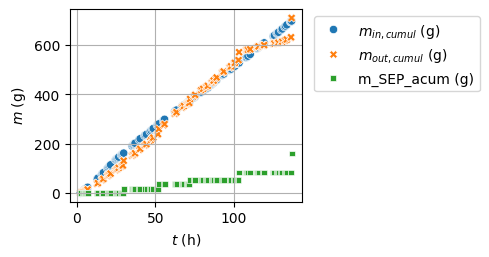

In [18]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = 'value',
             data=data[['t_h',
                        '$m_{in,cumul}$ (g)', 
                        '$m_{out,cumul}$ (g)',
                        'm_SEP_acum (g)',
                       ]].melt(id_vars = 't_h'), 
             hue = 'variable',
             style = 'variable',
             ax = ax)

plt.grid('both')
# plt.ylim(0,1)
# plt.xlim(0,10)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.xlabel('$t$ (h)')
plt.ylabel('$m$ (g)')
fig_name = 'MB_cumul.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

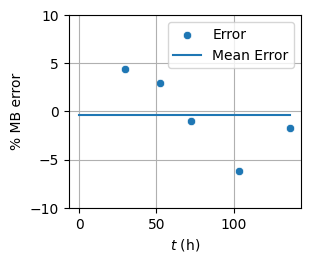

In [19]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = 'MB_error_perc',
             data=data.loc[data['LIQ_SAMPLE'] == 1],
             label = 'Error',
             ax = ax)

plt.grid('both')
plt.plot(np.linspace(0, data['t_h'].iloc[-1], 2), 
         (data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean(), 
          data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean()), 
         label = 'Mean Error')
plt.ylim(-10,10)
# plt.xlim(0,80)
plt.legend()
plt.xlabel('$t$ (h)')
plt.ylabel('% MB error')
fig_name = 'MB_error.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [20]:
data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean()

np.float64(-0.31878217483665955)

In [21]:
# now closing the mass balance using the integral mass balance to get the aprox liquid % in the outlet

In [22]:
data['$m_{total}$ (g/s)'] = data['$m_{liq,out}$ (g/s)'] + data['$m_{gas,out}$ (g/s)']

# recalculating gas outlet molar flow rates on reconciled data
data['F_gas_out (mol/s)'] = (data['F_H2_s_mol_s'] + data['F_CO_s_mol_s'] + data['F_CH4_s_mol_s']
                            + data['F_CO2_s_mol_s'] + data['F_C2H4_s_mol_s']
                             + data['F_C2H6_s_mol_s'] + data['F_C3H8_s_mol_s']
                            )
data['y_H2_out'] = data['F_H2_s_mol_s']/data['F_gas_out (mol/s)']
data['y_CO_out'] = data['F_CO_s_mol_s']/data['F_gas_out (mol/s)']
data['y_CH4_out'] = data['F_CH4_s_mol_s']/data['F_gas_out (mol/s)']
data['y_CO2_out'] = data['F_CO2_s_mol_s']/data['F_gas_out (mol/s)']
data['y_C2H4_out'] = data['F_C2H4_s_mol_s']/data['F_gas_out (mol/s)']
data['y_C2H6_out'] = data['F_C2H6_s_mol_s']/data['F_gas_out (mol/s)']
data['y_C3H8_out'] = data['F_C3H8_s_mol_s']/data['F_gas_out (mol/s)']
data['MM_mean_gas'] = (data['y_H2_out']*2 + data['y_CO_out']*(12+16) + data['y_CH4_out']*16
                  + data['y_CO2_out']*44 + data['y_C2H6_out']*((2*12)+6) + data['y_C2H4_out']*((2*12)+4) + data['y_C3H8_out']*((3*12)+8))
data['F_gas_out (mol/s)'] = data['$m_{gas,out}$ (g/s)']/data['MM_mean_gas']
data['F_H2_s_mol_s'] = data['y_H2_out']*data['F_gas_out (mol/s)']
data['F_CO_s_mol_s'] = data['y_CO_out']*data['F_gas_out (mol/s)']
data['F_CH4_s_mol_s'] = data['y_CH4_out']*data['F_gas_out (mol/s)']
data['F_CO2_s_mol_s'] = data['y_CO2_out']*data['F_gas_out (mol/s)']
data['F_C2H4_s_mol_s'] = data['y_C2H4_out']*data['F_gas_out (mol/s)']
data['F_C2H6_s_mol_s'] = data['y_C2H6_out']*data['F_gas_out (mol/s)']
data['F_C3H8_s_mol_s'] = data['y_C3H8_out']*data['F_gas_out (mol/s)']

In [23]:
# recalculating inlet flow
y_H2_in = data['F_H2_e_mol_s'] / ( data['F_H2_e_mol_s'] + data['F_CO_e_mol_s'] )
y_CO_in = data['F_CO_e_mol_s'] / ( data['F_H2_e_mol_s'] + data['F_CO_e_mol_s'] )
MM_in = 2 * y_H2_in + 28 * y_CO_in
F_in = data['$m_{total}$ (g/s)'] / MM_in
data['F_H2_e_mol_s'] = y_H2_in * F_in
data['F_CO_e_mol_s'] = y_CO_in * F_in

In [24]:
data['$m_{liq,out}$ (g/s)'].mean()

np.float64(0.00031764649056997363)

In [25]:
# using oxygen elemental balance to correct water flow and get a better estimation of liquid hydrocarbon flow
data['F_H2O_s_mol_s'] = data['F_CO_e_mol_s'] - data['F_CO_s_mol_s'] - 2*data['F_CO2_s_mol_s']
data['$m_{H_2O,out}$ (g/s)'] = data['F_H2O_s_mol_s']*18

In [26]:
# fração de cera no produto líquido medida na balanca
# antes da correção pelo BM da água
data['frac_cera'].mean()

np.float64(0.3494168548097545)

In [27]:
# m C5+ out after H2O elemental balance correction
data['$m_{C5+,out}$ (g/s)'] = data['$m_{liq,out}$ (g/s)'] - data['$m_{H_2O,out}$ (g/s)']
data['$m_{C5+,out}$ (g/s)'].mean()

np.float64(0.00012782325053274906)

In [28]:
data['$m_{H_2O,out}$ (g/s)'].mean()

np.float64(0.00018982324003722454)

In [29]:
# fração de cera no produto líquido depois da correção pelo BM da água
data['frac_cera'] = data['$m_{C5+,out}$ (g/s)']/data['$m_{liq,out}$ (g/s)']
data['frac_cera'].mean()

np.float64(0.40469871978411603)

In [30]:
data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
     'F_Olef_C7', 'F_Olef_C8', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
     ]] = data[[
       'w_C9', 'w_C10', 'w_C11', 'w_C12', 'w_C13', 'w_C14', 'w_C15', 'w_C16',
       'w_C17', 'w_C18', 'w_C19', 'w_C20', 'w_C21', 'w_C22', 'w_C23', 'w_C24',
       'w_C25', 'w_C26', 'w_C27', 'w_C28', 'w_C29', 'w_C30', 'w_C31', 'w_C32',
       'w_C33', 'w_C34', 'w_C35', 'w_C36',
        'w_C7_olef', 'w_C8_olef',
       'w_C9_olef', 'w_C10_olef', 'w_C11_olef', 'w_C12_olef', 'w_C13_olef',
       'w_C14_olef', 'w_C15_olef', 'w_C16_olef', 'w_C17_olef', 'w_C18_olef'       
               ]].multiply(
    data['$m_{C5+,out}$ (g/s)'], axis = 'index')

# molar masses of liquid hydrocarbons
MM_PARAFIN = [n*12+2*n+2 for n in range(9,37)]
MM_OLEF = [n*12+2*n for n in range(9,19)]
MM = np.concat((MM_PARAFIN, MM_OLEF))

# to remove Performance Warning
# PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 
# `frame.insert` many times, which has poor performance.  Consider joining all columns 
# at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
data = data.copy()

# F = mass flow/molar mass
data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
     ]] = data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
                                 ]].divide(MM, axis = 1)
data = data.copy()

/tmp/ipykernel_10558/1736902401.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[['F_C9', 'F_C10',


In [31]:
data['T_R_C'] = data['T_R_K'] - 273.15
data['H2_CO'] = data['F_H2_e_mol_s']/data['F_CO_e_mol_s']
data['F_C1_C3_exp'] = (data['F_CH4_s_mol_s'] + data['F_C2H4_s_mol_s'] 
                       + data['F_C2H6_s_mol_s'] + data['F_C3H8_s_mol_s'])
data['F_C5+_exp'] = data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C7', 'F_Olef_C8', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
       ]].sum(axis=1)
# data['alpha'] = (
#         (2.48e-15*data['P_abs_Pa']**2 - 1.19e-8*data['P_abs_Pa'] + 0.01597)*data['T_R_K'] +
#         (-1.5397e-12*data['P_abs_Pa']**2 + 6.8763e-6*data['P_abs_Pa'] - 7.7249)*(data['F_H2_e_mol_s']/data['F_CO_e_mol_s'])
#         )

In [32]:
# recalculating X on reconciled data
data['X_CO'] = (data['F_CO_e_mol_s'] - data['F_CO_s_mol_s']) / data['F_CO_e_mol_s']
data['X_H2'] = (data['F_H2_e_mol_s'] - data['F_H2_s_mol_s']) / data['F_H2_e_mol_s']

In [33]:
# save reconciled data
with open('reconciled_data.pkl', 'wb') as f:
    pickle.dump(data, f)

In [34]:
data.to_excel('reconciled_data.ods')

In [35]:
kinetic_data = data.loc[data['CINÉTICA'] == 1.0].reset_index()
plot_data = data.loc[(data['DESATIVAÇÃO'] == 1.0) | (data['CINÉTICA'] == 1.0)].reset_index()
deactivation_data = data.loc[data['DESATIVAÇÃO'] == 1.0].reset_index()
data_mass_T = pd.read_excel('data_mass_T.ods')
data_mass_T = data_mass_T.loc[data_mass_T['MASS_T'] == 1.0].reset_index()
data_mass_T['-r_CO'] = -(data_mass_T['F_CO_s_mol_s'] - data_mass_T['F_CO_e_mol_s'])/data_mass_T['m_cat_g']
data_mass_T['-r_H2'] = -(data_mass_T['F_H2_s_mol_s'] - data_mass_T['F_H2_e_mol_s'])/data_mass_T['m_cat_g']
data_mass_T['T_R_C'] = data_mass_T['T_R_K'] - 273.15

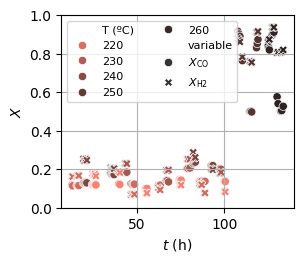

In [36]:
fig, ax = plt.subplots(figsize=(3,2.5))
plot_data_kinetics = data.loc[~(data.T_R_C > 250) | ~(data.X_CO < 0.4)].loc[(data.CINÉTICA == True) 
    & (data.DESATIVAÇÃO == False)][['t_h', 'X_CO', 'X_H2', 'T_R_C']]
plot_data_kinetics.columns = ['t (h)', '$X_\mathrm{CO}$', '$X_\mathrm{H2}$', 'T (ºC)']
plot_data_kinetics = plot_data_kinetics.melt(id_vars = ['t (h)', 'T (ºC)'])
sns.scatterplot(data = plot_data_kinetics,
               x = 't (h)', y = 'value', hue = 'T (ºC)', style = 'variable', palette = 'dark:salmon_r')

plt.grid('both')
plt.ylim(0,1)
# plt.xlim(0,80)
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.legend(ncols = 2, fontsize = 8)
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
fig_name = 'X_kinetics.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

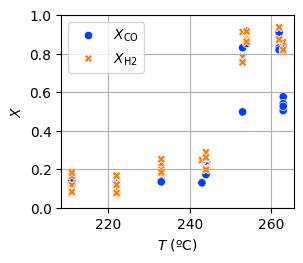

In [37]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(data = plot_data_kinetics,
               x = 'T (ºC)', y = 'value', hue = 'variable', style = 'variable', palette = 'bright')

plt.grid('both')
plt.ylim(0,1)
# plt.xlim(0,80)
plt.legend(title=None)
plt.xlabel('$T$ (ºC)')
plt.ylabel('$X$')
fig_name = 'X_vs_T.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

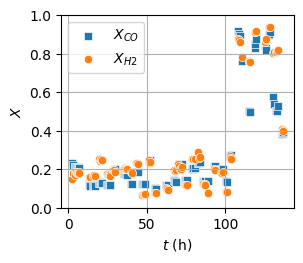

In [38]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y='X_CO',
             data=data, ax = ax, marker = 's', label = '$X_{CO}$')
sns.scatterplot(x='t_h', y='X_H2',
             data=data, ax = ax, marker = 'o', label = '$X_{H2}$')

plt.grid('both')
plt.ylim(0,1)
# plt.xlim(0,80)
plt.legend(title=None)
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
plt.show()

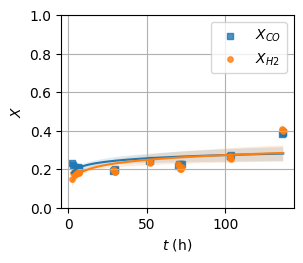

In [39]:
fig, ax = plt.subplots(figsize=(3,2.5))
line_w = 1.5
scatter_s = 15
sns.regplot(x='t_h', y='X_CO',
             data=deactivation_data, logx = True, 
            ax = ax, marker = 's', label = '$X_{CO}$',
           line_kws = {'linewidth': line_w}, scatter_kws= {'s': scatter_s})
sns.regplot(x='t_h', y='X_H2',
             data=deactivation_data, logx = True, 
            ax = ax, marker = 'o', label = '$X_{H2}$',
           line_kws = {'linewidth': line_w}, scatter_kws= {'s': scatter_s})

plt.grid('both')
plt.legend()
plt.ylim(0,1)
# plt.xlim(0,80)
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
fig_name = 'X_deactivation.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

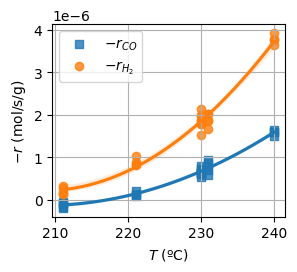

In [40]:
fig, ax = plt.subplots(figsize=(3,2.5))
# sns.lineplot(x='T_R_C', y='-r_CO',
#              data=data_mass_T, ax = ax)
sns.regplot(x='T_R_C', y='-r_CO',
             data=data_mass_T, ax = ax, marker = 's', label = '$-r_{CO}$', order = 2)
# sns.lineplot(x='T_R_C', y='-r_H2',
#              data=data_mass_T, ax = ax)
sns.regplot(x='T_R_C', y='-r_H2',
             data=data_mass_T, ax = ax, marker = 'o', label = '$-r_{H_2}$', order = 2)

plt.grid('both')
plt.legend()
# plt.ylim(0,None)
plt.xlabel('$T$ (ºC)')
plt.ylabel('$-r$ (mol/s/g)')
fig_name = 'T_vs_r_mass_T.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()